In [1]:
import os
os.chdir("/home/wergillius/Project/PINN_dynamics")
import sys
import numpy as np
import pandas as pd

In [2]:
import scanpy as sc
import palantir

In [3]:
import matplotlib.pyplot as plt

In [10]:
ad = sc.read_h5ad("data/combined_filt.h5ad")

# read the cellbarcode and compute density

In [7]:
ery_mk = pd.read_csv("data/input_pseudo_dyn_ery_mk_dpt_feb_22_with_index.csv", index_col=0)
ery_mk_ad = ad[ery_mk.index].copy()
ery_mk_ad.obs['branch'] = ery_mk.loc[ery_mk_ad.obs_names, 'pseudodynamics_branch_class'].values
ery_mk_ad

AnnData object with n_obs × n_vars = 22740 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

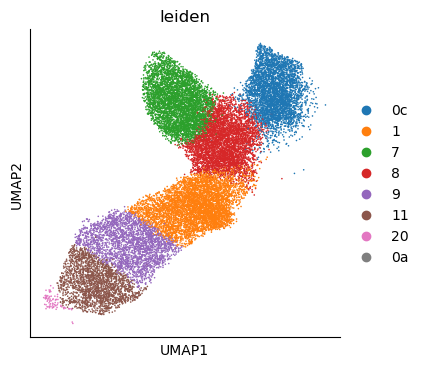

In [27]:
sc.pl.umap(ery_mk_ad, color='leiden')

In [92]:
import seaborn as sns

In [96]:
ery_mk_ad

AnnData object with n_obs × n_vars = 22740 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

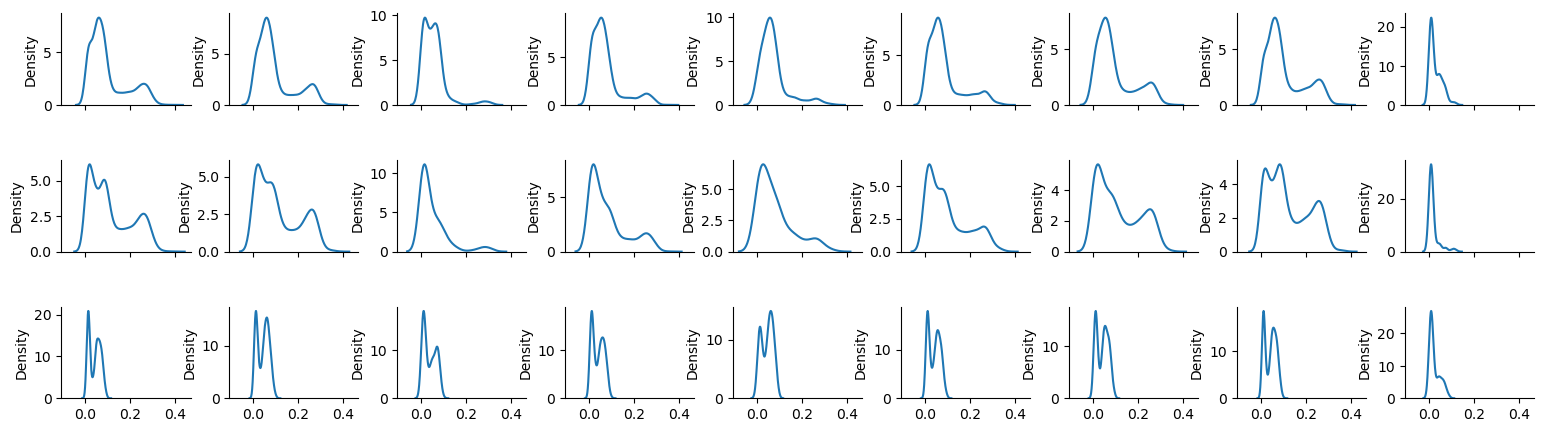

In [106]:
fig, axs = plt.subplots(3, 9, figsize=(19,5),  gridspec_kw={'hspace':0.6 ,'wspace':0.3})

for i_t, t in enumerate(ery_mk_ad.obs['timepoint_tx_days'].unique()):
    obs_t = ery_mk_ad.obs.query("`timepoint_tx_days` == @t")

    #  fate probability density
    # sns.kdeplot(ad_t.obsm['palantir_fate_probabilities']['mk'], ax=axs[0,i_t], label='mk')
    
    sns.kdeplot(obs_t.dpt_pseudotime.values, ax=axs[0, i_t], label='ery')
    
    sns.kdeplot(obs_t.query("`branch` != 'mk'").dpt_pseudotime.values, ax=axs[1, i_t], label='ery')

    #  plt
    # sns.kdeplot(ad_t[ad_t.obsm['branch_masks']['mk']].obs['palantir_pseudotime'].values, ax=axs[1,i_t], label='mk')
    sns.kdeplot(obs_t.query("`branch` != 'ery'").dpt_pseudotime.values, ax=axs[2, i_t], label='mk')



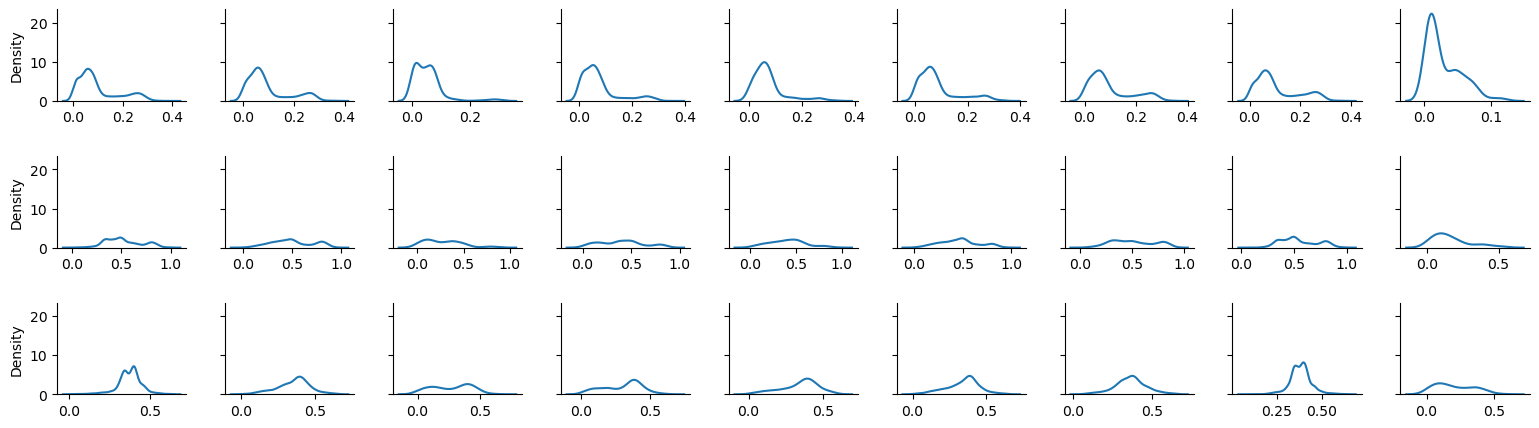

In [109]:
fig, axs = plt.subplots(3, 9, figsize=(19,5), sharey=True,  gridspec_kw={'hspace':0.6 ,'wspace':0.3})

for i_t, t in enumerate(ery_mk_ad.obs['timepoint_tx_days'].unique()):
    obs_t = ery_mk_ad.obs.query("`timepoint_tx_days` == @t")

    #  fate probability density
    # sns.kdeplot(ad_t.obsm['palantir_fate_probabilities']['mk'], ax=axs[0,i_t], label='mk')
    
    sns.kdeplot(obs_t.dpt_pseudotime.values, ax=axs[0, i_t], label='ery')
    
    sns.kdeplot(obs_t.query("`branch` != 'mk'").palantir_pseudotime.values, ax=axs[1, i_t], label='ery')

    #  plt
    # sns.kdeplot(ad_t[ad_t.obsm['branch_masks']['mk']].obs['palantir_pseudotime'].values, ax=axs[1,i_t], label='mk')
    sns.kdeplot(obs_t.query("`branch` != 'ery'").palantir_pseudotime.values, ax=axs[2, i_t], label='mk')



# run palantir

In [8]:
# Run diffusion maps
dm_res = palantir.utils.run_diffusion_maps(ery_mk_ad)

/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
ms_data = palantir.utils.determine_multiscale_space(ery_mk_ad)

### magic impute expression

In [10]:
imputed_X = palantir.utils.run_magic_imputation(ery_mk_ad)

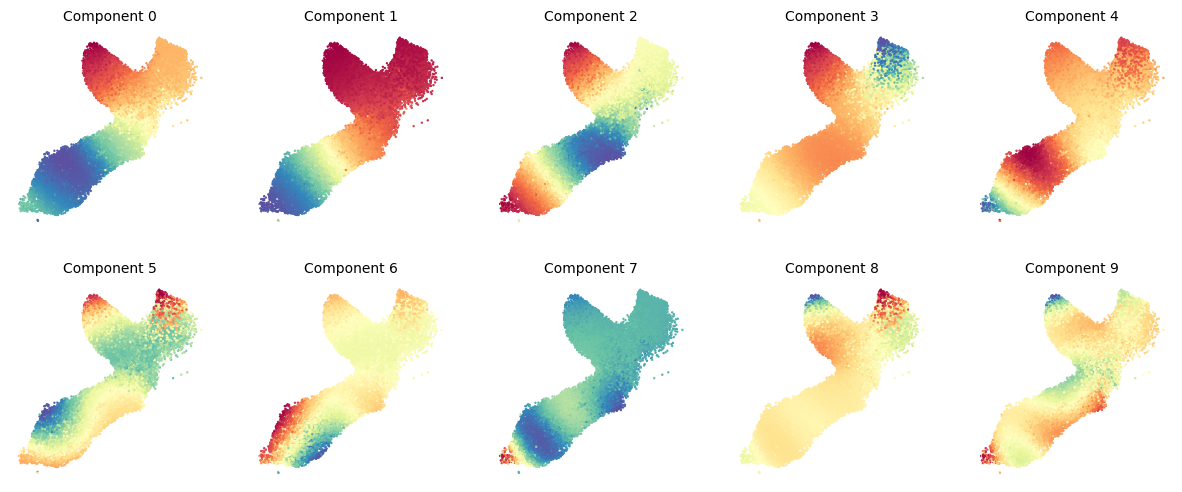

In [11]:
palantir.plot.plot_diffusion_components(ery_mk_ad)
plt.show()

In [12]:
# terminal mk
mk_terminal_idx = ery_mk.query('`pseudodynamics_branch_class` == "mk"').dpt_pseudotime.argmax()
mk_terminal_cb = ery_mk.query('`pseudodynamics_branch_class` == "mk"').iloc[mk_terminal_idx].name
print(mk_terminal_cb)

# terminal ery
ery_terminal_idx = ery_mk.query('`pseudodynamics_branch_class` == "ery"').dpt_pseudotime.argmax()
ery_terminal_cb = ery_mk.query('`pseudodynamics_branch_class` == "ery"').iloc[ery_terminal_idx].name
print(ery_terminal_cb)

# root
root_idx = ery_mk.dpt_pseudotime.argmin()
root_cb = ery_mk.iloc[root_idx].name
print(root_cb)

5mo_SIGAD9_CCCTAACGTTCTCACC-1-10x
9mo_SIGAE3_TCTAACTGTCGTCATA-1-10x
7w11w_SITTC3_ACTATCTGTACAGCGA-1-10x


In [13]:
all_states = pd.Series(
    ["mk", "ery", "root"],
    index=[mk_terminal_cb, ery_terminal_cb, root_cb],
)

terminal_states = pd.Series(
    ["mk", "ery"],
    index=[mk_terminal_cb, ery_terminal_cb],
)

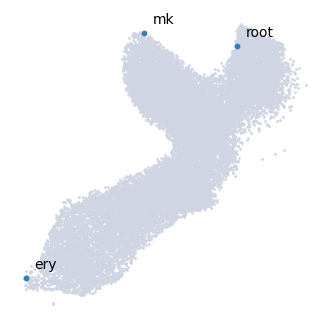

In [14]:
palantir.plot.highlight_cells_on_umap(ery_mk_ad, all_states)
plt.show()

In [15]:
start_cell = root_cb
pr_res = palantir.core.run_palantir(
    ery_mk_ad, start_cell, num_waypoints=500, terminal_states=terminal_states
)

Sampling and flocking waypoints...
Time for determining waypoints: 0.013170150915781657 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...


Time for shortest paths: 0.4350659489631653 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9996
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


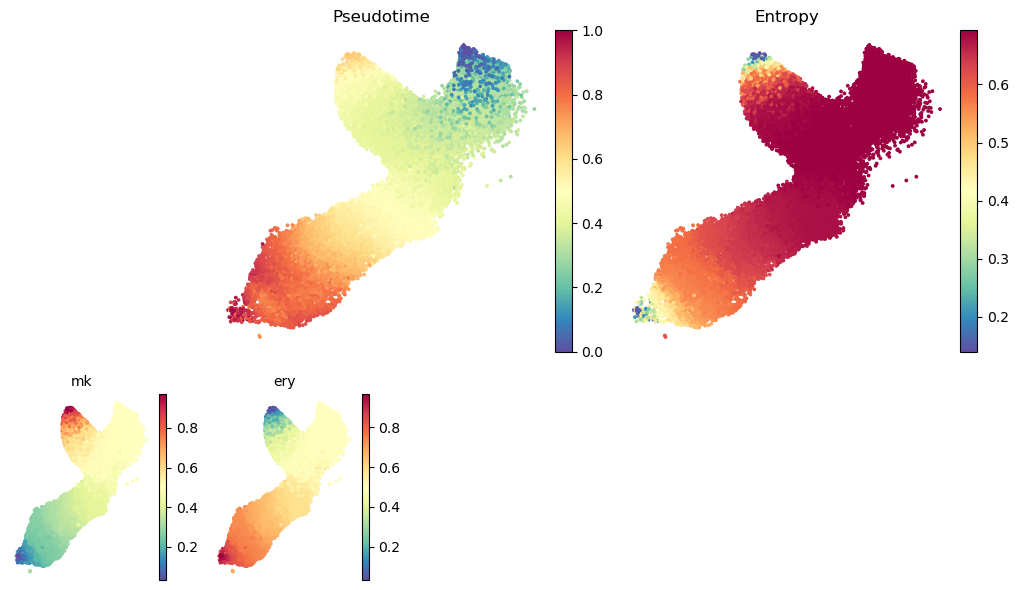

In [16]:
palantir.plot.plot_palantir_results(ery_mk_ad, s=3)
plt.show()

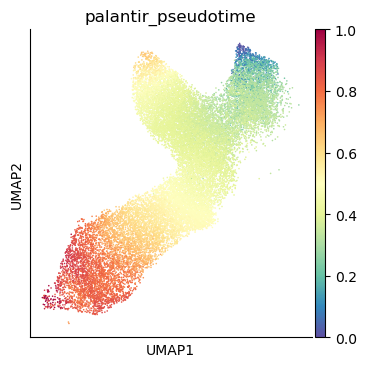

In [17]:
sc.pl.umap(ery_mk_ad, color=['palantir_pseudotime'], )

# branch

In [29]:
masks = palantir.presults.select_branch_cells(ery_mk_ad, q=.02, eps=.02)

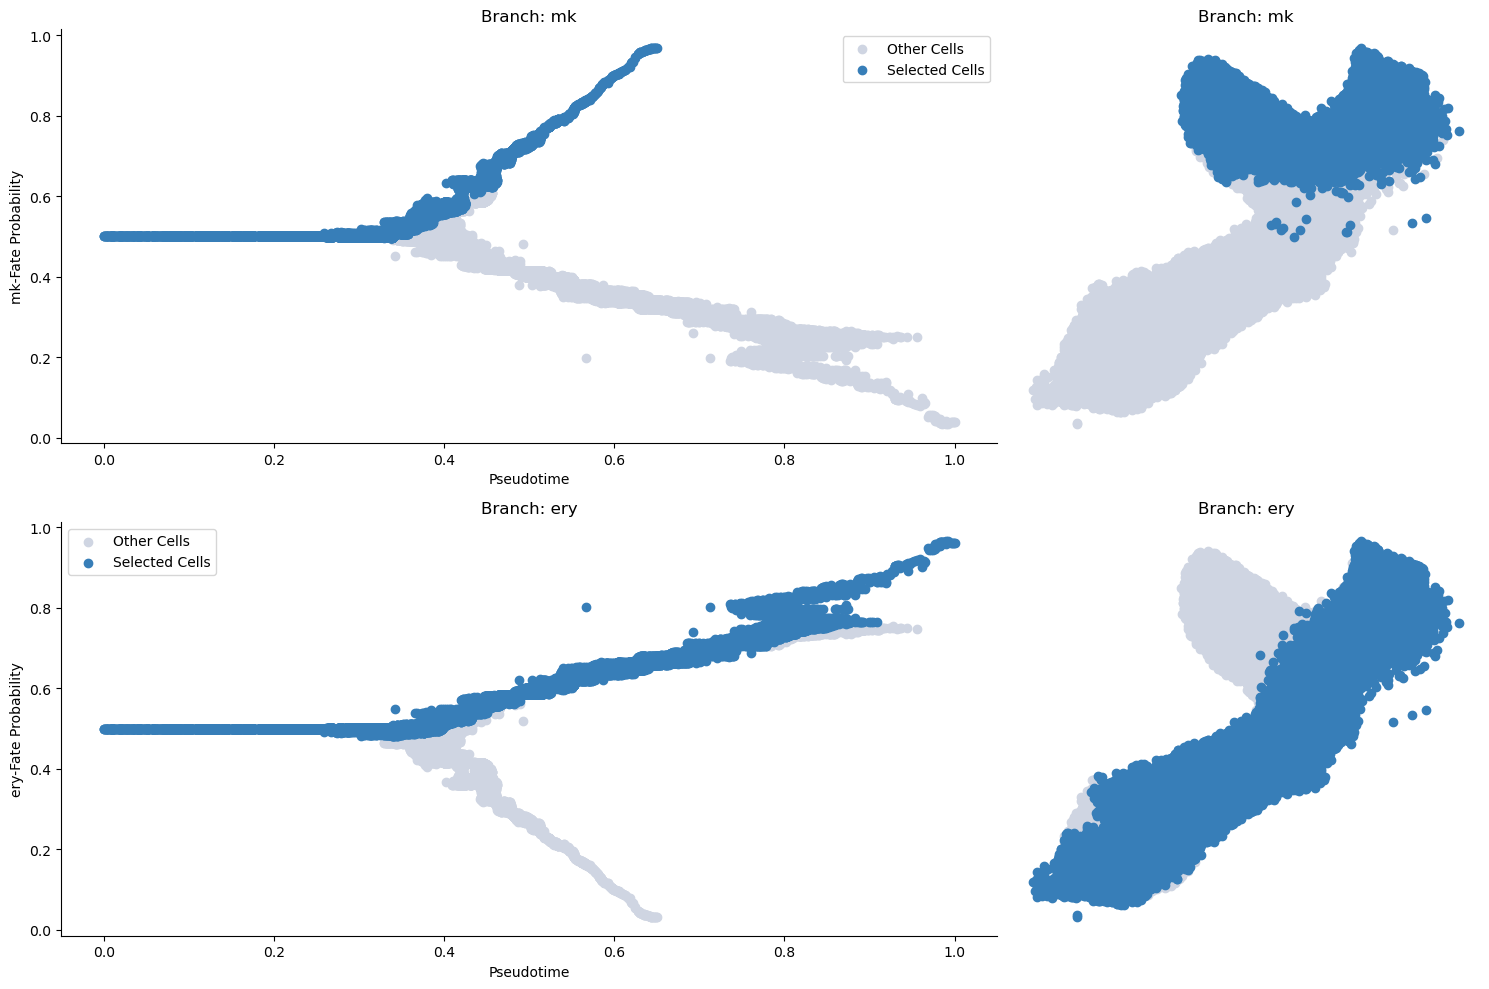

In [30]:
palantir.plot.plot_branch_selection(ery_mk_ad)
plt.show()

[2024-06-25 17:56:38,711] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (12,850) and rank = 1.0.
[2024-06-25 17:56:38,711] [INFO    ] Using covariance function Matern52(ls=1.3595992088317872).
[2024-06-25 17:56:38,740] [INFO    ] Computing 50 landmarks with k-means clustering.


<Axes: title={'center': 'Branch: ery'}>

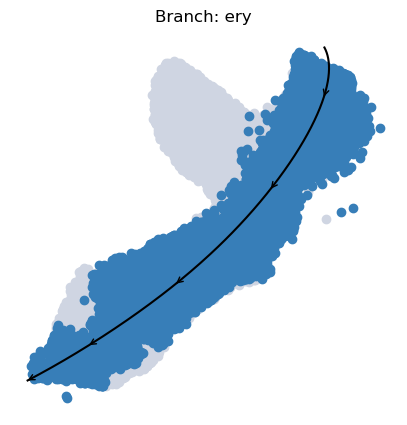

In [27]:
palantir.plot.plot_trajectory(ery_mk_ad, "ery")

[2024-06-25 17:56:39,893] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (5,414) and rank = 1.0.
[2024-06-25 17:56:39,894] [INFO    ] Using covariance function Matern52(ls=1.3595992088317872).
[2024-06-25 17:56:39,919] [INFO    ] Computing 50 landmarks with k-means clustering.


<Axes: title={'center': 'Branch: mk'}>

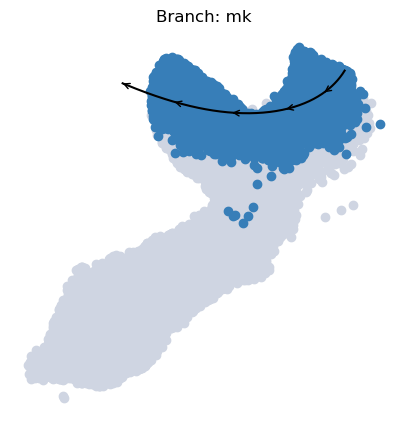

In [28]:
palantir.plot.plot_trajectory(ery_mk_ad, "mk")

## find gene trend

In [31]:
ery_mk_ad

AnnData object with n_obs × n_vars = 22740 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [32]:
gene_trends = palantir.presults.compute_gene_trends(
    ery_mk_ad,
    expression_key="MAGIC_imputed_data",
)

mk
[2024-06-25 17:59:37,382] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (8,202) and rank = 1.0.
[2024-06-25 17:59:37,383] [INFO    ] Using covariance function Matern52(ls=1.0).
ery
[2024-06-25 17:59:40,447] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (16,078) and rank = 1.0.
[2024-06-25 17:59:40,448] [INFO    ] Using covariance function Matern52(ls=1.0).


find the differentially expressed genes

In [11]:
ery_mk_ad.obs.leiden.cat.categories
deg_df = sc.get.rank_genes_groups_df(ad, group=['1', '7', '8', '9', '11', '20', '0'])
deg_df.head(3)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,1,Apoe,343.784821,3.737821,0.0,0.0
1,1,Vamp5,236.484879,2.286741,0.0,0.0
2,1,S100a10,210.204803,1.992044,0.0,0.0


In [12]:
diff_degs = deg_df.query("`pvals_adj` < 0.01 & `logfoldchanges` > 2").names.values
diff_degs = np.unique([g for g in diff_degs if g in ery_mk_ad.var_names])
print(len(diff_degs))

449


## ery related genes

/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


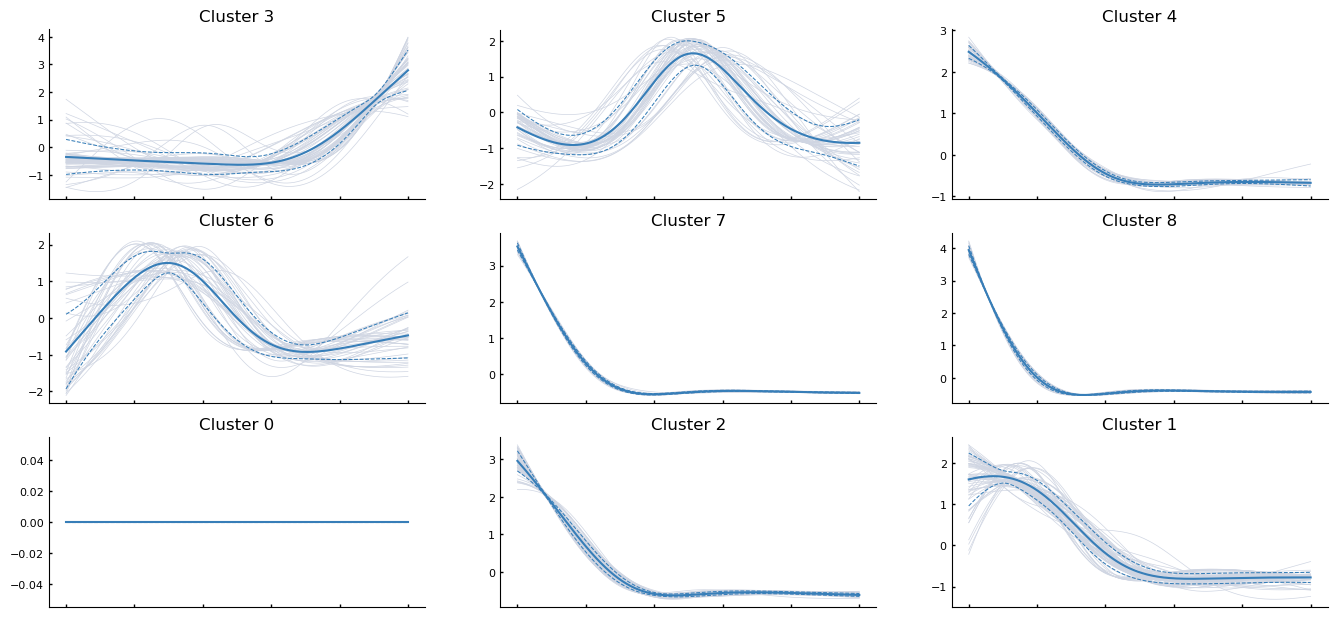

In [62]:
# of 
communities = palantir.presults.cluster_gene_trends(ery_mk_ad, 
    "ery", diff_degs, n_neighbors = 20)


palantir.plot.plot_gene_trend_clusters(ery_mk_ad, "ery")
plt.show()

## mk related genes

/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


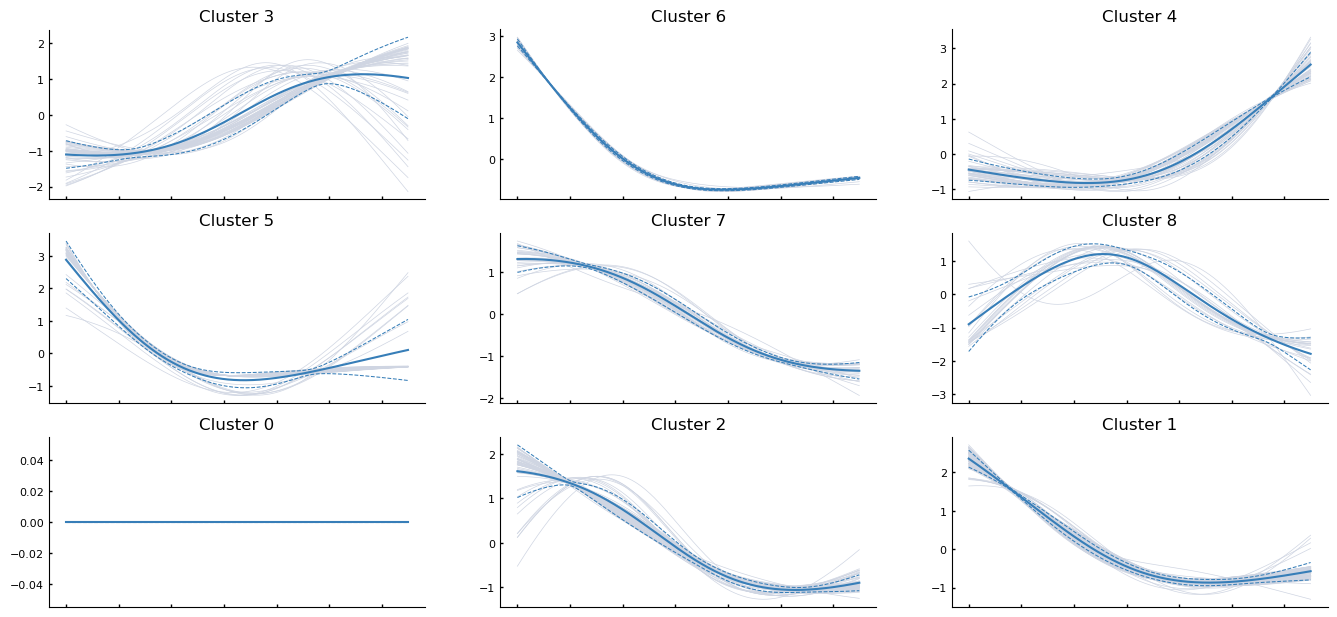

In [63]:
# of 
communities = palantir.presults.cluster_gene_trends(ery_mk_ad, 
    "mk", diff_degs, n_neighbors = 20)


palantir.plot.plot_gene_trend_clusters(ery_mk_ad, "mk")
plt.show()

### find gene with the highest correlation

In [9]:
from scipy.stats import pearsonr, spearmanr

In [18]:
from tqdm import tqdm

In [19]:
for gene in tqdm(diff_degs):
    pass

100%|██████████| 449/449 [00:00<00:00, 1342296.86it/s]


## ery trajectory

In [36]:
ery_ad = ery_mk_ad[ery_mk_ad.obsm['branch_masks']['ery']]
pseudotime = ery_ad.obs.palantir_pseudotime.values.reshape(-1,1)

(16078, 1) (16078, 449)


In [49]:
expression = ery_ad.layers['MAGIC_imputed_data']

ery_R = []
ery_Rou = []
i = 0

for i in tqdm(range(ery_mk_ad.shape[1])):
    ery_R.append(pearsonr(expression[:,i], pseudotime.flatten())[0])
    ery_Rou.append(spearmanr(expression[:,i], pseudotime.flatten())[0])
    i+=1
    
ery_R = np.array(ery_R)
ery_R = np.where(np.isnan((ery_R)), 0, ery_R)
ery_mk_ad.var['ery_Magic_pdt_r'] = ery_R

ery_Rou = np.array(ery_Rou)
ery_Rou = np.where(np.isnan((ery_Rou)), 0, ery_Rou)
ery_mk_ad.var['ery_Magic_pdt_spr'] = ery_Rou

  0%|          | 0/4814 [00:00<?, ?it/s]/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
  0%|          | 11/4814 [00:00<03:15, 24.54it/s]

100%|██████████| 4814/4814 [00:52<00:00, 91.60it/s] 


In [81]:
expression = ery_ad.X.A

ery_R = []
i = 0
for i in tqdm(range(ery_mk_ad.shape[1])):
    ery_R.append(pearsonr(expression[:,i], pseudotime.flatten())[0])
    i+=1
    
ery_R = np.array(ery_R)
ery_R = np.where(np.isnan((ery_R)), 0, ery_R)
ery_mk_ad.var['ery_X_pdt_r'] = ery_R

  0%|          | 4/4814 [00:00<02:09, 37.18it/s]

  0%|          | 14/4814 [00:00<02:26, 32.80it/s]/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
100%|██████████| 4814/4814 [01:50<00:00, 43.70it/s] 


In [199]:
ery_top_genes = ery_mk_ad.var[['symbol','ery_Magic_pdt_spr', 'ery_Magic_pdt_r', 'ery_X_pdt_r']].sort_values('ery_Magic_pdt_r', ascending=False)
ery_genes = ery_top_genes.iloc[:10].index
ery_top_genes.head()

,symbol,ery_Magic_pdt_spr,ery_Magic_pdt_r,ery_X_pdt_r
Kcnn4,Kcnn4,0.906293,0.917591,0.262907
Mrpl52,Mrpl52,0.948014,0.914509,0.493579
Kel,Kel,0.967745,0.899340,0.398343
Gfi1b,Gfi1b,0.848910,0.888420,0.348225
Zdhhc14,Zdhhc14,0.913195,0.871559,0.205778


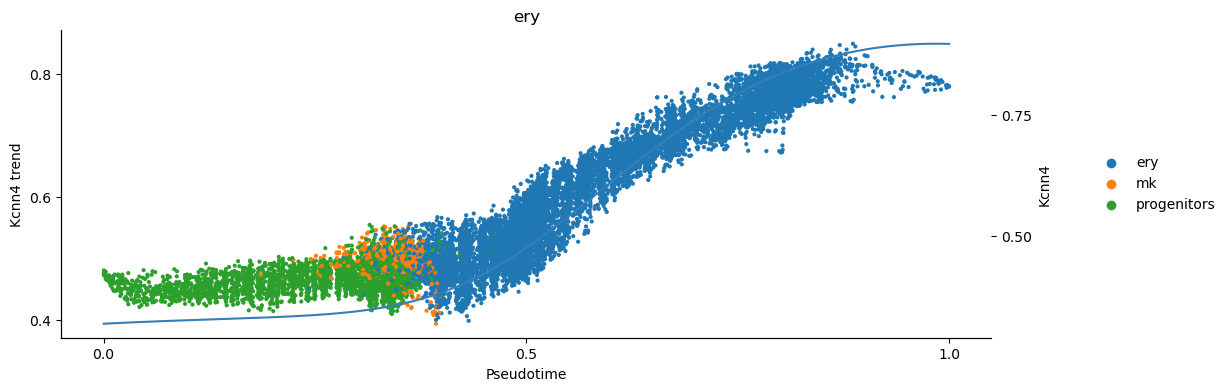

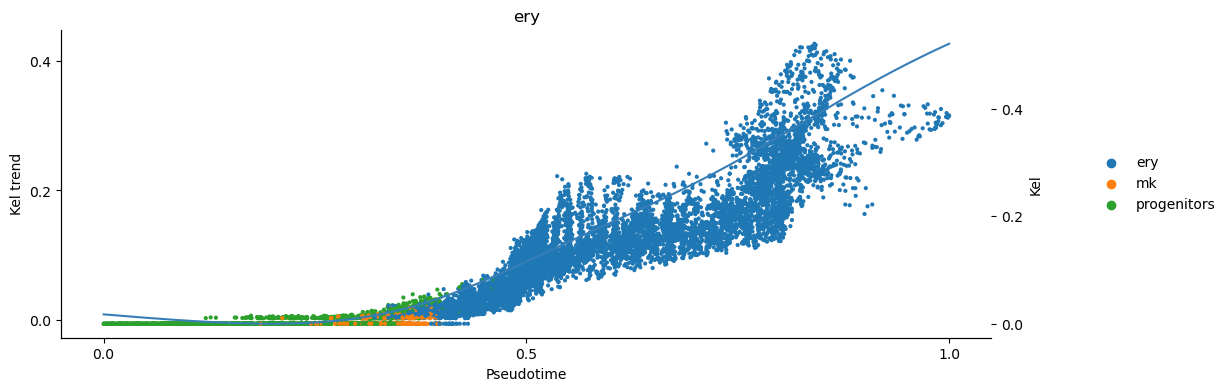

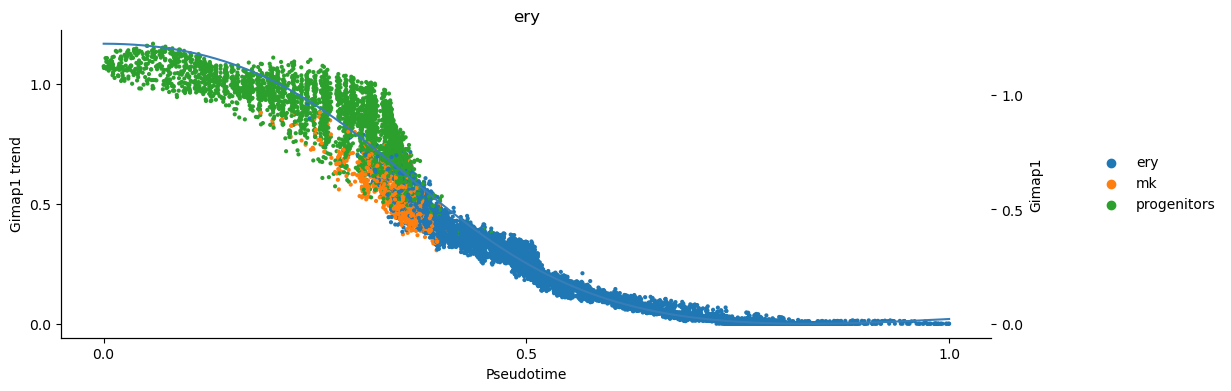

In [110]:
palantir.plot.plot_trend(ery_ad, "ery", "Kcnn4", color="branch", position_layer="MAGIC_imputed_data")
palantir.plot.plot_trend(ery_ad, "ery", "Kel", color="branch", position_layer="MAGIC_imputed_data")
palantir.plot.plot_trend(ery_ad, "ery", "Gimap1", color="branch", position_layer="MAGIC_imputed_data")
plt.show()

/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1359: FutureWarning: In a future version of AnnData, access to `.X` by passing `layer='X'` will be removed. Instead pass `layer=None`.
  warnings.warn(
/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1359: FutureWarning: In a future version of AnnData, access to `.X` by passing `layer='X'` will be removed. Instead pass `layer=None`.
  warnings.warn(


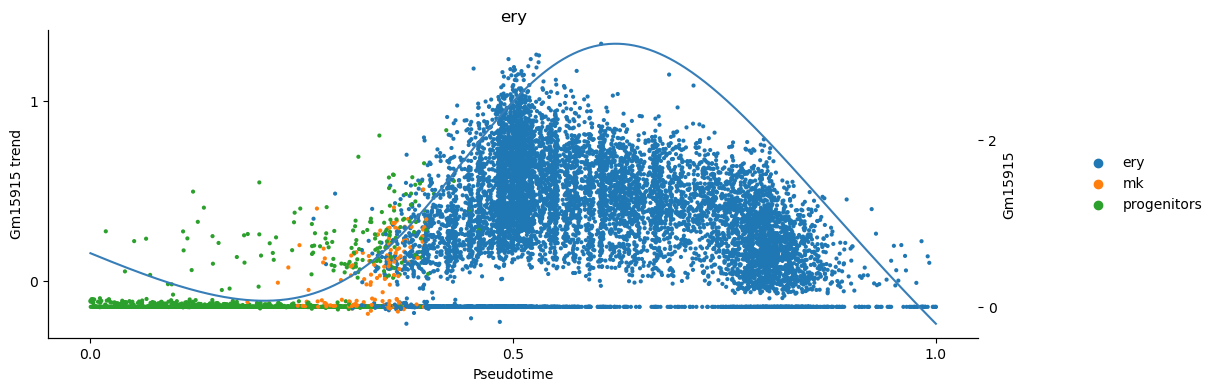

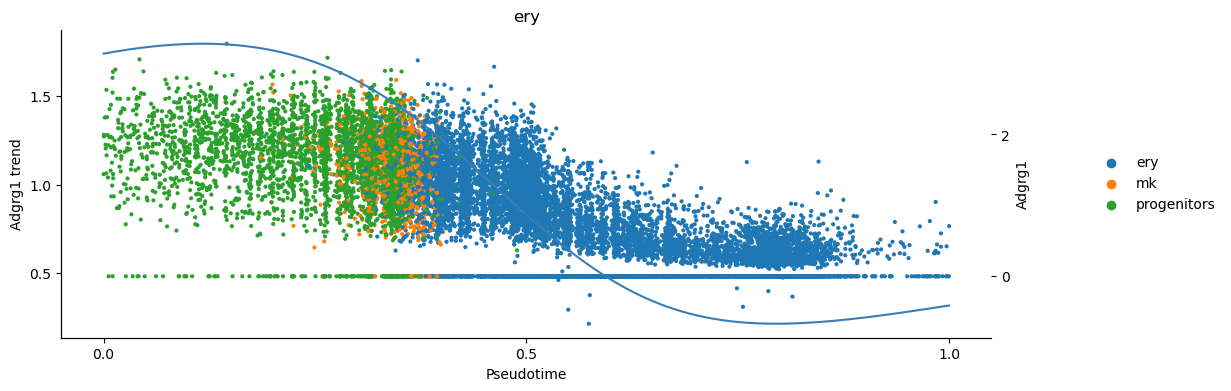

In [87]:
palantir.plot.plot_trend(ery_ad, "ery", "Gm15915", color="branch", position_layer="X")
palantir.plot.plot_trend(ery_ad, "ery", "Adgrg1", color="branch", position_layer="X")
plt.show()

## mk trajectory

In [88]:
mk_ad = ery_mk_ad[ery_mk_ad.obsm['branch_masks']['mk']]

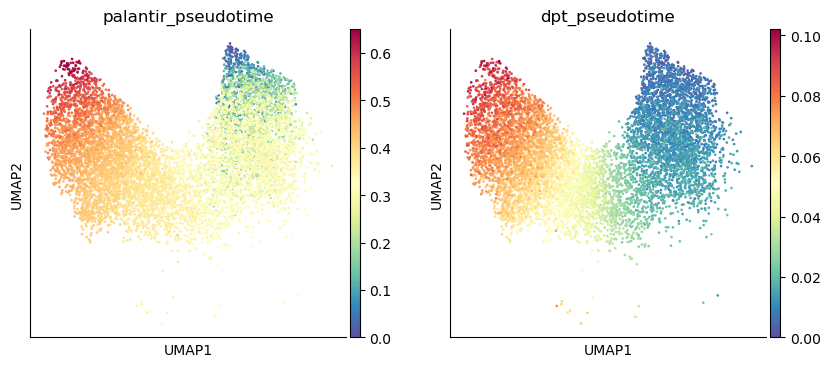

In [95]:
sc.pl.umap(mk_ad, color=['palantir_pseudotime', 'dpt_pseudotime'])

In [99]:
expression = mk_ad.layers['MAGIC_imputed_data']
pseudotime = mk_ad.obs.palantir_pseudotime.values.reshape(-1,1)

mk_R = []
mk_Rou = []
i = 0
for i in tqdm(range(ery_mk_ad.shape[1])):
    mk_R.append(pearsonr(expression[:,i], pseudotime.flatten())[0])
    mk_Rou.append(spearmanr(expression[:,i], pseudotime.flatten())[0])
    i+=1
    
mk_R = np.array(mk_R)
mk_R = np.where(np.isnan((mk_R)), 0, mk_R)
ery_mk_ad.var['mk_Magic_pdt_r'] = mk_R

mk_Rou = np.array(mk_Rou)
mk_Rou = np.where(np.isnan((mk_Rou)), 0, mk_Rou)
ery_mk_ad.var['mk_Magic_pdt_spr'] = mk_Rou

  0%|          | 0/4814 [00:00<?, ?it/s]/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
100%|██████████| 4814/4814 [00:02<00:00, 2286.72it/s]


In [90]:
expression = mk_ad.X.A

mk_R = []
i = 0
for i in tqdm(range(ery_mk_ad.shape[1])):
    mk_R.append(pearsonr(expression[:,i], pseudotime.flatten())[0])
    i+=1
    
mk_R = np.array(mk_R)
mk_R = np.where(np.isnan((mk_R)), 0, mk_R)
ery_mk_ad.var['mk_X_pdt_r'] = mk_R

  0%|          | 0/4814 [00:00<?, ?it/s]/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
  5%|▌         | 259/4814 [00:00<00:03, 1299.93it/s]

100%|██████████| 4814/4814 [00:03<00:00, 1392.46it/s]


In [198]:
mk_top_genes = ery_mk_ad.var[['symbol', "mk_Magic_pdt_spr",'mk_Magic_pdt_r', 'mk_X_pdt_r']].sort_values('mk_Magic_pdt_r', ascending=False)
mk_genes = mk_top_genes.iloc[:10].index
mk_top_genes.head()

,symbol,mk_Magic_pdt_spr,mk_Magic_pdt_r,mk_X_pdt_r
Actb,Actb,0.958672,0.970605,0.515620
Crip1,Crip1,0.852100,0.909462,0.388007
Rabgap1l,Rabgap1l,0.957289,0.903642,0.619374
Plek,Plek,0.970385,0.898411,0.688870
Gp5,Gp5,0.953911,0.893919,0.512401


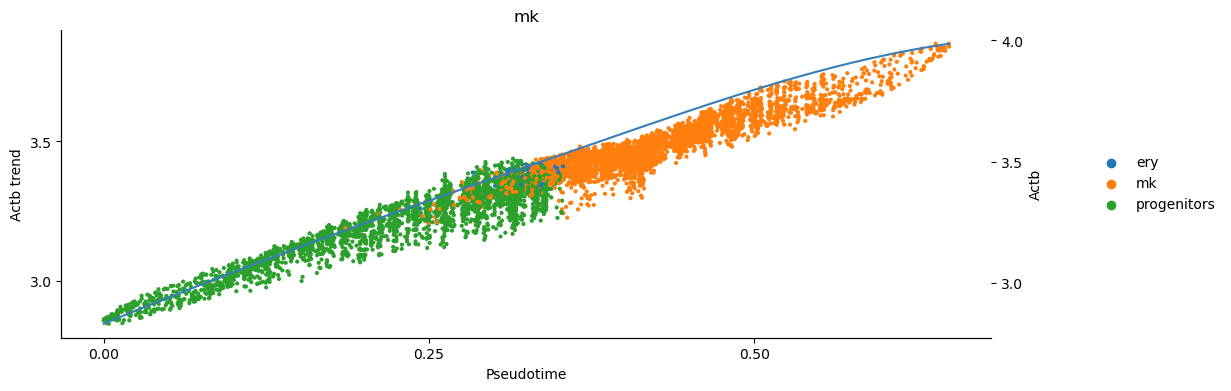

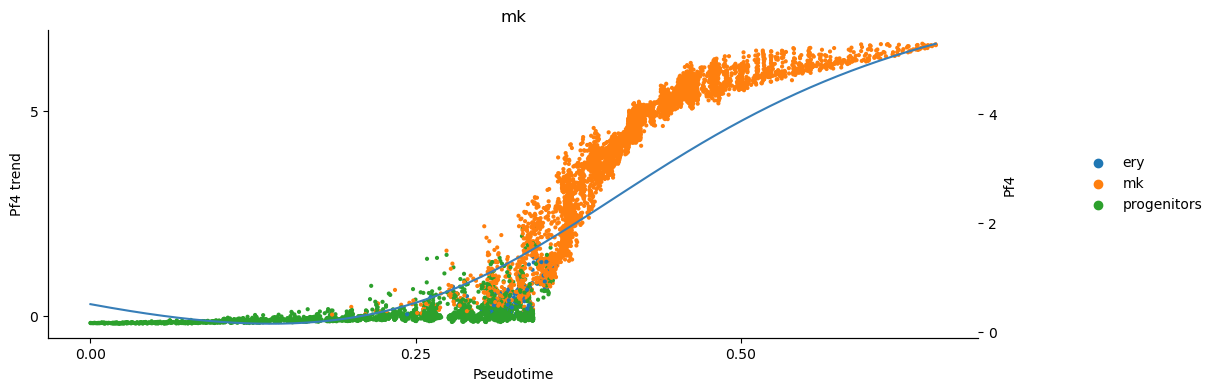

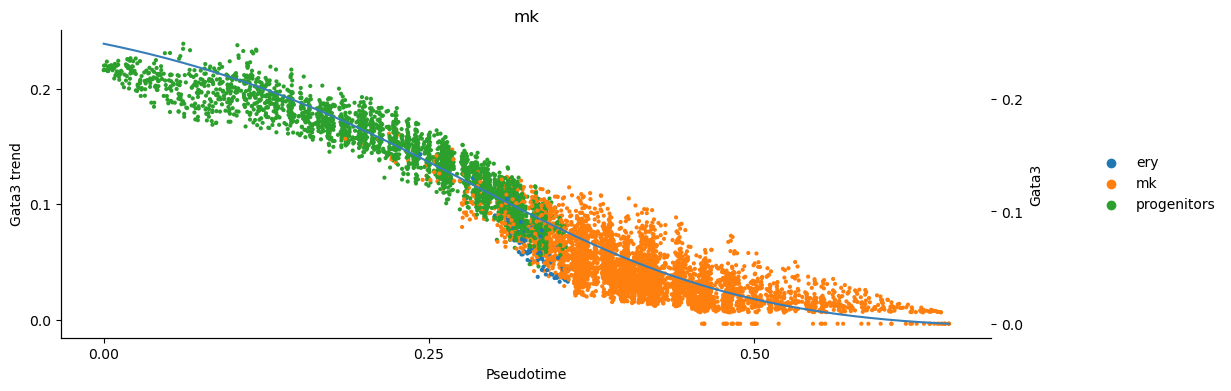

In [109]:
palantir.plot.plot_trend(mk_ad, "mk", "Actb", color="branch", position_layer="MAGIC_imputed_data")
palantir.plot.plot_trend(mk_ad, "mk", "Pf4", color="branch", position_layer="MAGIC_imputed_data")
palantir.plot.plot_trend(mk_ad, "mk", "Gata3", color="branch", position_layer="MAGIC_imputed_data")
plt.show()

In [106]:
ery_mk_ad.write_h5ad("data/ery_mk.h5ad")

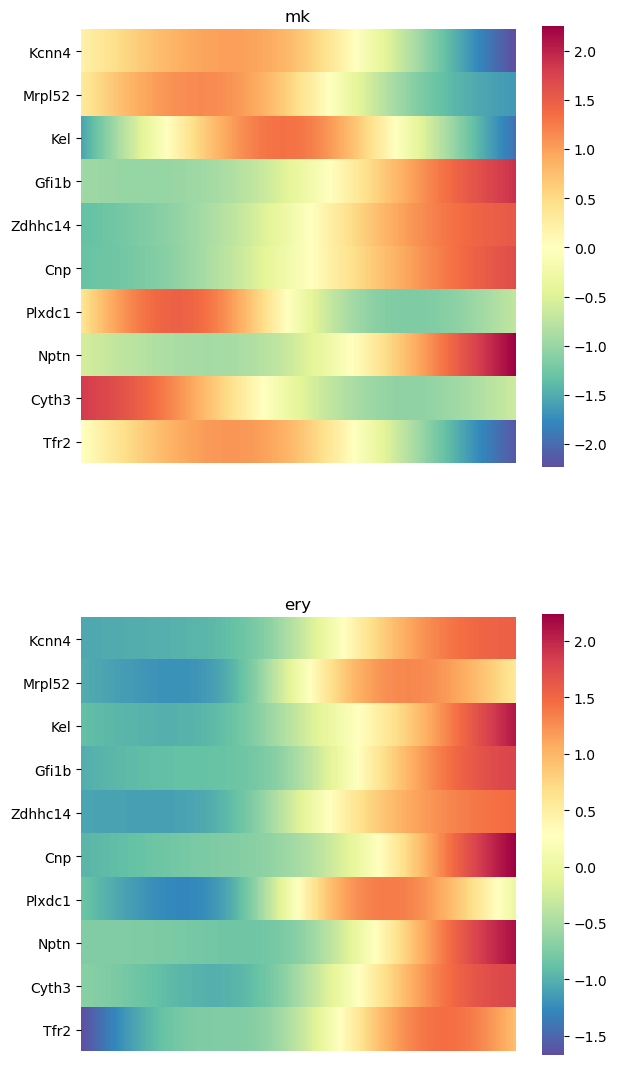

In [203]:
palantir.plot.plot_gene_trend_heatmaps(ery_mk_ad, ery_genes);

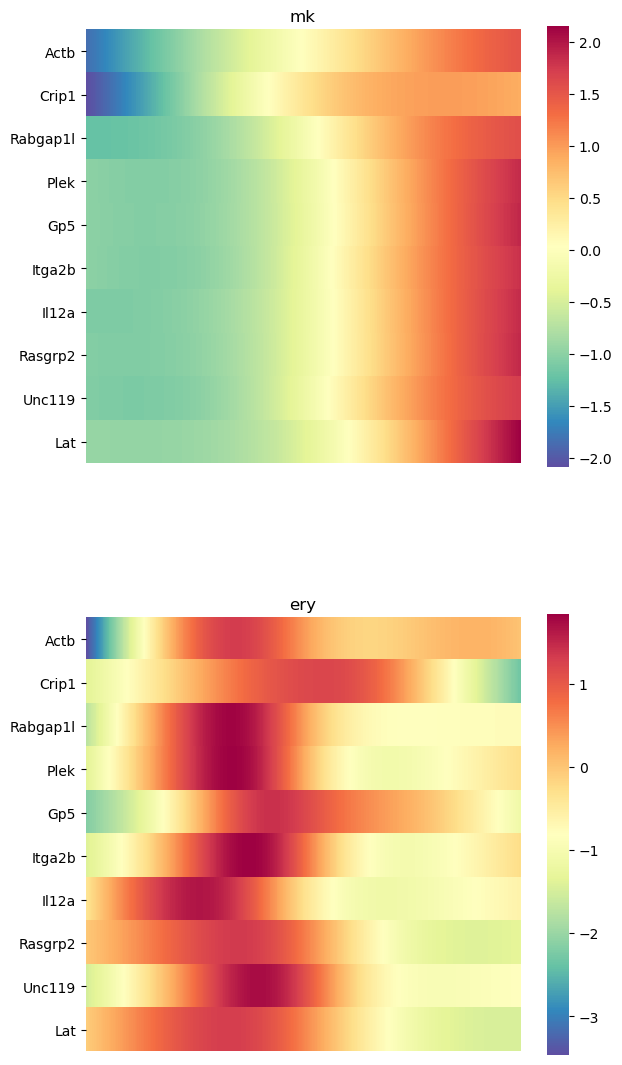

In [204]:
palantir.plot.plot_gene_trend_heatmaps(ery_mk_ad, mk_genes);

## Density

Let's take `Actb` for mk and `Kcnn4` for ery

In [112]:
# cell state coordinates
S = ery_mk_ad[:,['Actb', 'Kcnn4']].layers['MAGIC_imputed_data']

# rescale S
S = (S - S.min(0).reshape(-1,2)) / (S.max(0) - S.min(0)).reshape(-1,2)
ery_mk_ad.obsm['Actb_Kcnn4_scaled_S'] = S

In [156]:
S.min(0), S.max(0)

(array([0., 0.], dtype=float32), array([1., 1.], dtype=float32))

Text(0.5, 1.0, 'Kcnn4 - Ery')

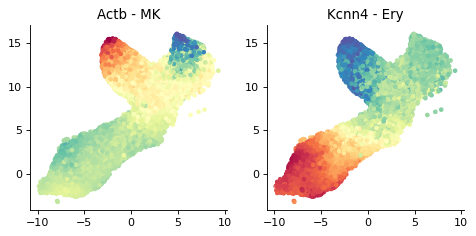

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(7,3), dpi=80)
X_umap = ery_mk_ad.obsm['X_umap']

axs[0].scatter(X_umap[:,0], X_umap[:,1], c=S[:,0], s=10)
axs[0].set_title("Actb - MK")

axs[1].scatter(X_umap[:,0], X_umap[:,1], c=S[:,1], s=10)
axs[1].set_title("Kcnn4 - Ery")

In [126]:
ery_mk_ad.write_h5ad("data/ery_mk.h5ad")

Let visualize the density change over time

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, 'Kcnn4 \n(Ery trajectory)')

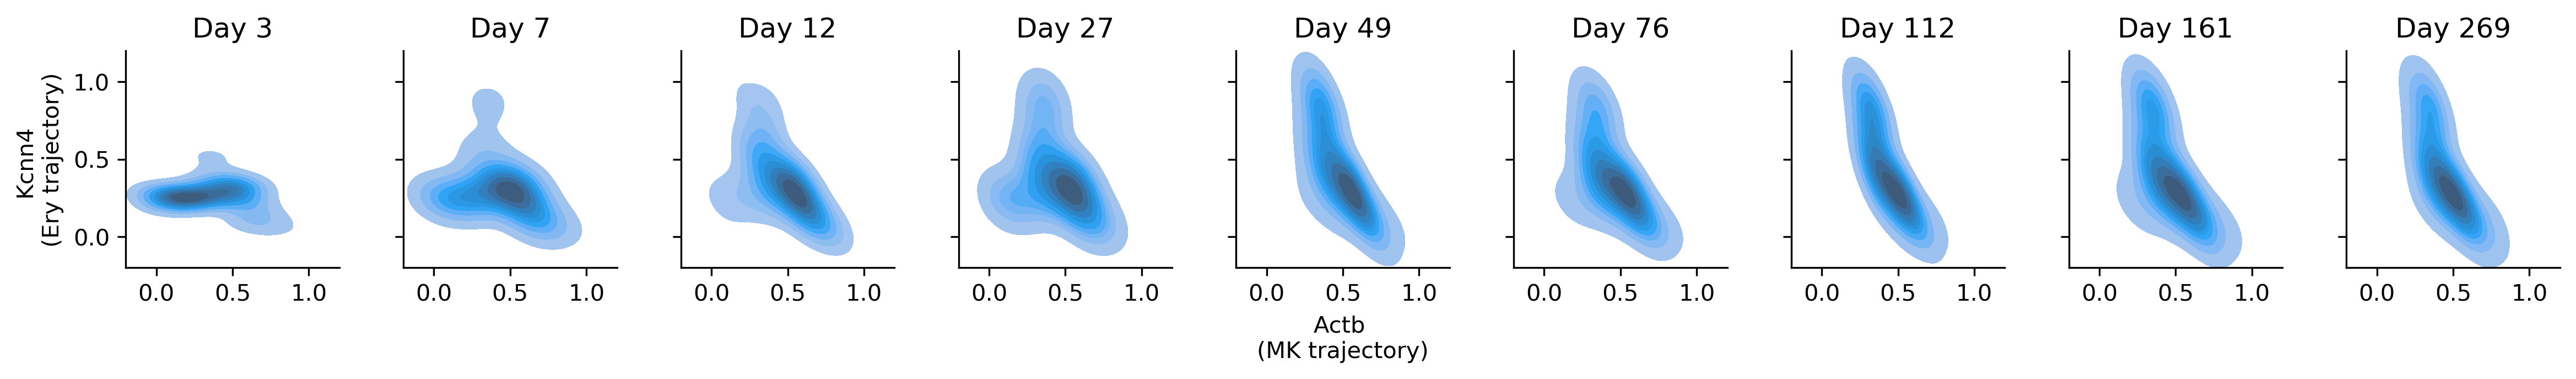

In [137]:
fig, axs = plt.subplots(1, 9, figsize=(19,1.7), dpi=300, sharey=True,  gridspec_kw={'hspace':0.6 ,'wspace':0.3})

for i_t, t in enumerate(sorted(ery_mk_ad.obs['timepoint_tx_days'].unique())):
    ad_t = ery_mk_ad[ery_mk_ad.obs.query("`timepoint_tx_days` == @t").index]
    
    sns.kdeplot(x=ad_t.obsm['Actb_Kcnn4_scaled_S'][:,0], 
                y=ad_t.obsm['Actb_Kcnn4_scaled_S'][:,1], 
                bw_method = 0.6,
                fill=True, ax=axs[i_t])

    axs[i_t].set_xlabel('')
    axs[i_t].set_title('Day %d' %(t))
    
    axs[i_t].set_ylim(-0.2,1.2)
    axs[i_t].set_xlim(-0.2,1.2)
    axs[i_t].set_xticks([0,0.5,1.0])
axs[4].set_xlabel('Actb \n(MK trajectory)')
axs[0].set_ylabel('Kcnn4 \n(Ery trajectory)')

In [120]:
density_fn = gaussian_kde(S.T, bw_method=0.8)

In [121]:
density_fn

# fate probability

In [4]:
ery_mk_ad = sc.read_h5ad("data/ery_mk.h5ad")

In [ ]:
ery_mk_ad.obsm_keys()

['DM_EigenVectors',
 'DM_EigenVectors_multiscaled',
 'X_diffmap',
 'X_pca',
 'X_pca_harmony',
 'X_pca_scaled',
 'X_umap',
 'X_umap_2d',
 'X_umap_3d',
 'X_umap_DM_2d',
 'X_umap_DM_3d',
 'branch_masks',
 'palantir_fate_probabilities',
 'Actb_Kcnn4_scaled_S']

In [138]:
ery_mk_ad.obsm['palantir_fate_probabilities']

,mk,ery
9mo_SIGAE3_AAACCCAAGACCTCAT-1-10x,0.590898,0.409102
9mo_SIGAE3_AAACGAAGTAACAGGC-1-10x,0.413496,0.586504
9mo_SIGAE3_AAACGAATCTACGGTA-1-10x,0.582110,0.417890
9mo_SIGAE3_AAACGCTAGCGTTCAT-1-10x,0.253105,0.746895
9mo_SIGAE3_AAACGCTTCCGTGCGA-1-10x,0.499395,0.500605
...,...,...
1276-SS2,0.500839,0.499161
1281-SS2,0.500839,0.499161
1282-SS2,0.528691,0.471309
1285-SS2,0.405344,0.594656


## density of fate probability, pseudotime, or magic smoothed genes

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, 'mk trajectory \n Density')

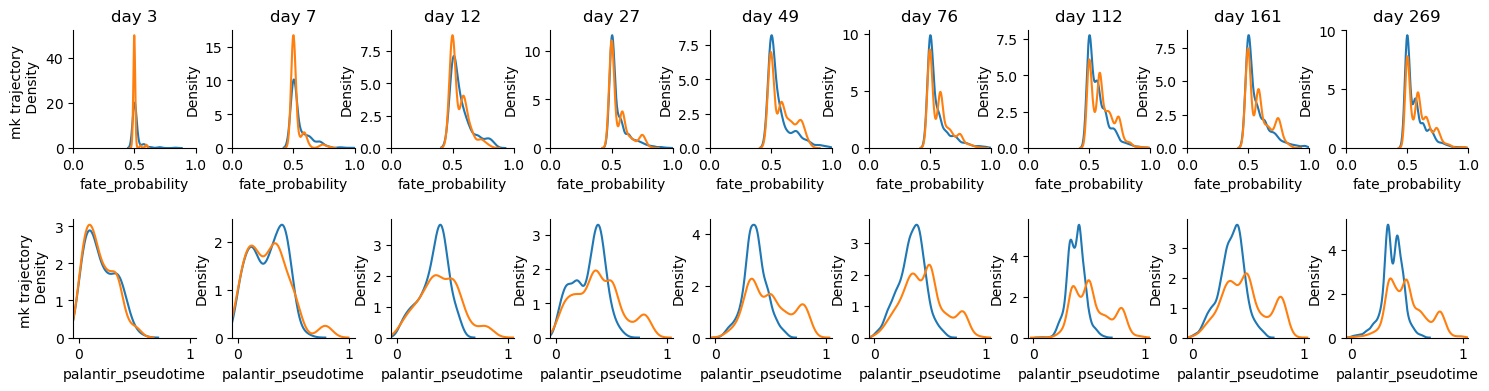

In [ ]:
fig, axs = plt.subplots(2, 9, figsize=(18,4), gridspec_kw={'hspace':0.6 ,'wspace':0.3})

for i_t, t in enumerate(sorted(ery_mk_ad.obs['timepoint_tx_days'].unique())):
    ad_t = ery_mk_ad[ery_mk_ad.obs.query("`timepoint_tx_days` == @t").index]

    mk_adt = ad_t[ad_t.obsm['branch_masks']['mk']]
    ery_adt = ad_t[ad_t.obsm['branch_masks']['ery']]

    #  fate probability density
    sns.kdeplot(mk_adt.obsm['palantir_fate_probabilities']['mk'], ax=axs[0,i_t], label='mk')
    sns.kdeplot(ery_adt.obsm['palantir_fate_probabilities']['ery'], ax=axs[0,i_t], label='ery')

    #  plt
    sns.kdeplot(mk_adt.obs['palantir_pseudotime'].values, ax=axs[1,i_t], label='mk')
    sns.kdeplot(ery_adt.obs['palantir_pseudotime'].values, ax=axs[1,i_t], label='ery')


    
    axs[0,i_t].set_title('day %d' %t)
    axs[0,i_t].set_xlabel('fate_probability')
    axs[0,i_t].set_xlim(0,1)
    axs[1,i_t].set_xlabel('palantir_pseudotime')
    axs[1,i_t].set_xlim(-0.05,1.05)

axs[0,0].legend(ncol=1)

axs[0,0].set_ylabel('mk trajectory \n Density')
axs[1,0].set_ylabel('mk trajectory \n Density')


In [147]:
# (n_cell,) -> (n_cell,2)
pseudotime = ery_mk_ad.obs.palantir_pseudotime.values.reshape(-1,1)
pseudotime = np.broadcast_to(pseudotime, (pseudotime.shape[0],2))

# make sure the 
Fate_P = ery_mk_ad.obsm['palantir_fate_probabilities'].values

In [242]:
# make sure the pseudotime and fate probability has the same shape
Fate_coord = np.multiply(Fate_P**1.5, pseudotime**0.3) 
Fate_coord.min(0), Fate_coord.max(0)

(array([0., 0.]), array([0.83727774, 0.94777967]))

In [243]:
# rescale to 0,1
Fate_coord = (Fate_coord - Fate_coord.min(0).reshape(-1,2)) / (Fate_coord.max(0) - Fate_coord.min(0)).reshape(-1,2)
Fate_coord.min(0), Fate_coord.max(0)

(array([0., 0.]), array([1., 1.]))

Text(0.5, 1.0, 'Kcnn4 dpt - Ery')

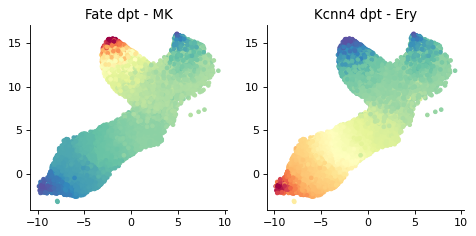

In [244]:
fig, axs = plt.subplots(1,2, figsize=(7,3), dpi=80)
X_umap = ery_mk_ad.obsm['X_umap']

coords = Fate_coord #ery_mk_ad.obsm['Fate_scaled_dpt']

axs[0].scatter(X_umap[:,0], X_umap[:,1], c=coords[:,0], s=10)
axs[0].set_title("Fate dpt - MK")

axs[1].scatter(X_umap[:,0], X_umap[:,1], c=coords[:,1], s=10)
axs[1].set_title("Kcnn4 dpt - Ery")

In [245]:
ery_mk_ad.obsm['Fate_scaled_dpt'] = Fate_coord

Text(0, 0.5, 'Ery trajectory)')

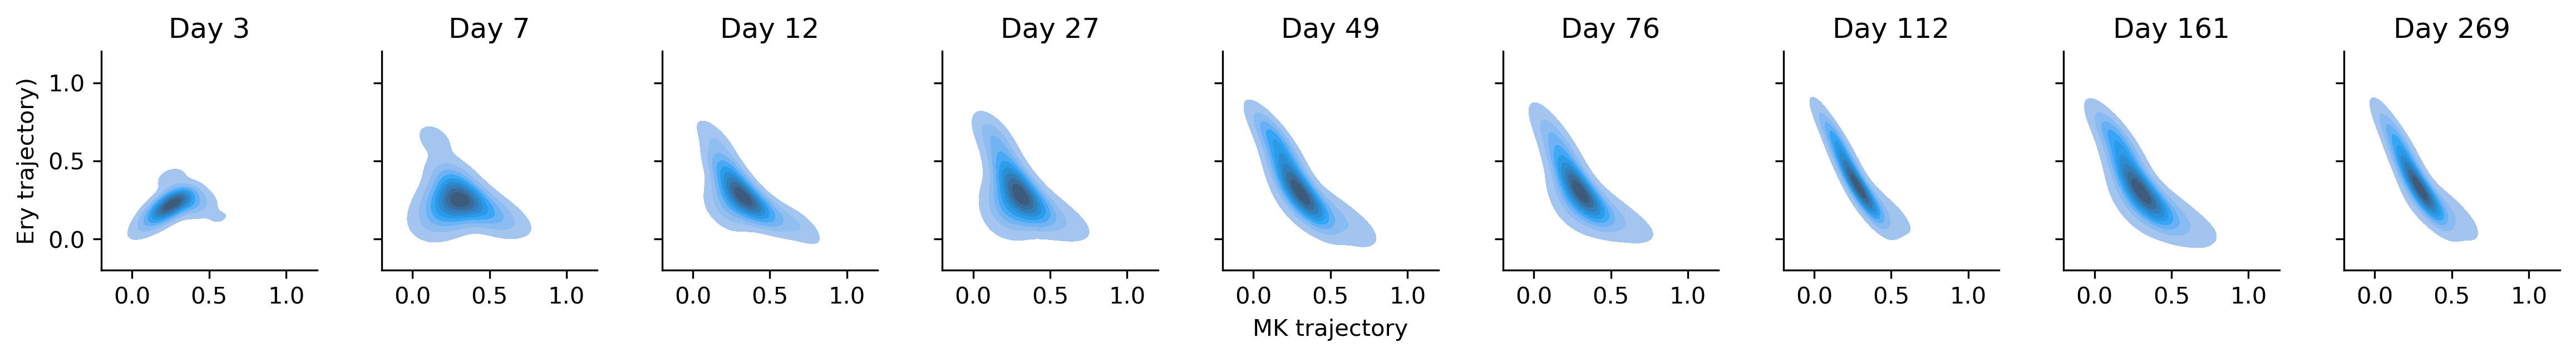

In [246]:
fig, axs = plt.subplots(1, 9, figsize=(19,1.7), dpi=300, sharey=True,  gridspec_kw={'hspace':0.6 ,'wspace':0.3})

for i_t, t in enumerate(sorted(ery_mk_ad.obs['timepoint_tx_days'].unique())):
    ad_t = ery_mk_ad[ery_mk_ad.obs.query("`timepoint_tx_days` == @t").index]
    
    sns.kdeplot(x=ad_t.obsm['Fate_scaled_dpt'][:,0], 
                y=ad_t.obsm['Fate_scaled_dpt'][:,1], 
                bw_method = 0.7,
                fill=True, ax=axs[i_t])

    axs[i_t].set_xlabel('')
    axs[i_t].set_title('Day %d' %(t))
    
    axs[i_t].set_ylim(-0.2,1.2)
    axs[i_t].set_xlim(-0.2,1.2)
    axs[i_t].set_xticks([0,0.5,1.0])
    
axs[4].set_xlabel('MK trajectory')
axs[0].set_ylabel('Ery trajectory)')

Text(0.5, 1.0, 'Fate - Ery')

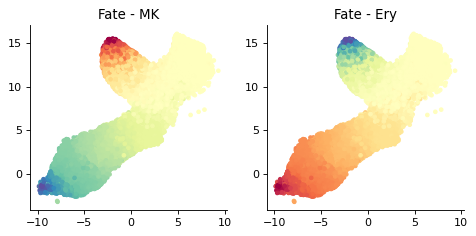

In [247]:
fig, axs = plt.subplots(1,2, figsize=(7,3), dpi=80)
X_umap = ery_mk_ad.obsm['X_umap']

coords = ery_mk_ad.obsm['palantir_fate_probabilities'].values

axs[0].scatter(X_umap[:,0], X_umap[:,1], c=coords[:,0], s=10)
axs[0].set_title("Fate - MK")

axs[1].scatter(X_umap[:,0], X_umap[:,1], c=coords[:,1], s=10)
axs[1].set_title("Fate - Ery")

In [248]:
ery_mk_ad.write_h5ad("data/ery_mk.h5ad")